### Bike Sharing Analysis:

These days Bike-Sharing has become a highly popular option to travel around cities, providing a fast, eco-friendly, and convenient way for individuals of different ages.  
This project examines various factors, such as weather, time of day, day of the week, or popular seasons, which can have an effect on the demands for bike-sharing services.  
The goal is to find patterns and predict requests according to the results that make sure enough bikes are available everywhere and every time people need them. It is all about making urban travel easier and more efficient for everyone!
#### Data Characteristics:
The dataset includes records aggregated on a daily and hourly basis:
#### Day Dataset:
Number of Observations: 731 daily records. Number of Variables: 16 features.
#### Hour Dataset:
Number of Observations: 17,379 hourly records. Number of Variables: 17 features.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load datasets
day_data = pd.read_csv("dataset/day.csv")
hour_data = pd.read_csv("dataset/hour.csv")

In [3]:
# Print some first records
print(day_data.head())
print(hour_data.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

In [4]:
pd.DataFrame({
    'count': day_data.count(),
    'min': day_data.min(),
    'max': day_data.max()
})

,count,min,max
instant,731,1,731
dteday,731,2011-01-01,2012-12-31
season,731,1,4
yr,731,0,1
mnth,731,1,12
holiday,731,0,1
weekday,731,0,6
workingday,731,0,1
weathersit,731,1,3
temp,731,0.05913,0.861667


In [5]:
pd.DataFrame({
    'count': hour_data.count(),
    'min': hour_data.min(),
    'max': hour_data.max()
})

,count,min,max
instant,17379,1,17379
dteday,17379,2011-01-01,2012-12-31
season,17379,1,4
yr,17379,0,1
mnth,17379,1,12
hr,17379,0,23
holiday,17379,0,1
weekday,17379,0,6
workingday,17379,0,1
weathersit,17379,1,4


In [6]:
# Number of rows and columns
print(day_data.shape)  
print(hour_data.shape)

(731, 16)
(17379, 17)


In [14]:
# Data summary information
print(day_data.info())
print(hour_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   record_index            731 non-null    int64         
 1   date                    731 non-null    datetime64[ns]
 2   season                  731 non-null    int64         
 3   year                    731 non-null    int64         
 4   month                   731 non-null    int64         
 5   is_holiday              731 non-null    int64         
 6   day_of_week             731 non-null    int64         
 7   is_working_day          731 non-null    int64         
 8   weather_condition       731 non-null    int64         
 9   temperature             731 non-null    float64       
 10  feels_like_temperature  731 non-null    float64       
 11  humidity                731 non-null    float64       
 12  wind_speed              731 non-null    float64   

In [80]:
# Convert 'dteday' to a datetime object in day.csv
day_data['dteday'] = pd.to_datetime(day_data['dteday'])

# Create and convert a datetime column in hour.csv by combining 'dteday' and 'hr'
hour_data['datetime'] = pd.to_datetime(hour_data['dteday']) + pd.to_timedelta(hour_data['hr'], unit='h')

In [ ]:
# Data summary information after converting to a datetime object
print(day_data.info())
print(hour_data.info())

In [ ]:
# Statistical summary for numeric fields
print(day_data.describe())
print(hour_data.describe())

### Data Cleaning:

In [16]:
# Number of missing values per column
print(day_data.isnull().sum())
print(hour_data.isnull().sum())

record_index              0
date                      0
season                    0
year                      0
month                     0
is_holiday                0
day_of_week               0
is_working_day            0
weather_condition         0
temperature               0
feels_like_temperature    0
humidity                  0
wind_speed                0
casual_users              0
registered_users          0
total_rentals             0
dtype: int64
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
datetime      0
dtype: int64


In [17]:
# Rename columns of Day Dataset for better readability and consistency
day_data.rename(
    columns={
        'instant': 'record_index',
        'dteday': 'date',
        'season': 'season',
        'yr': 'year',
        'mnth': 'month',
        'holiday': 'is_holiday',
        'weekday': 'day_of_week',
        'workingday': 'is_working_day',
        'weathersit': 'weather_condition',
        'temp': 'temperature',
        'atemp': 'feels_like_temperature',
        'hum': 'humidity',
        'windspeed': 'wind_speed',
        'casual': 'casual_users',
        'registered': 'registered_users',
        'cnt': 'total_rentals'
    },
    inplace=True
)

In [18]:
print(day_data.columns)

Index(['record_index', 'date', 'season', 'year', 'month', 'is_holiday',
       'day_of_week', 'is_working_day', 'weather_condition', 'temperature',
       'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users',
       'registered_users', 'total_rentals'],
      dtype='object')


In [22]:
# Rename columns of Hour Dataset for better readability and consistency
hour_data.rename(
    columns={
        'instant': 'record_index',
        'dteday': 'date',
        'season': 'season',
        'yr': 'year',
        'mnth': 'month',
        'hr': 'hour',
        'holiday': 'is_holiday',
        'weekday': 'day_of_week',
        'workingday': 'is_working_day',
        'weathersit': 'weather_condition',
        'temp': 'temperature',
        'atemp': 'feels_like_temperature',
        'hum': 'humidity',
        'windspeed': 'wind_speed',
        'casual': 'casual_users',
        'registered': 'registered_users',
        'cnt': 'total_rentals'
    },
    inplace=True
)

In [23]:
print(hour_data.columns)

Index(['record_index', 'date', 'season', 'year', 'month', 'hour', 'is_holiday',
       'day_of_week', 'is_working_day', 'weather_condition', 'temperature',
       'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users',
       'registered_users', 'total_rentals', 'datetime'],
      dtype='object')


### The plot shows hourly trends throughout the day to help understand bike demand patterns:

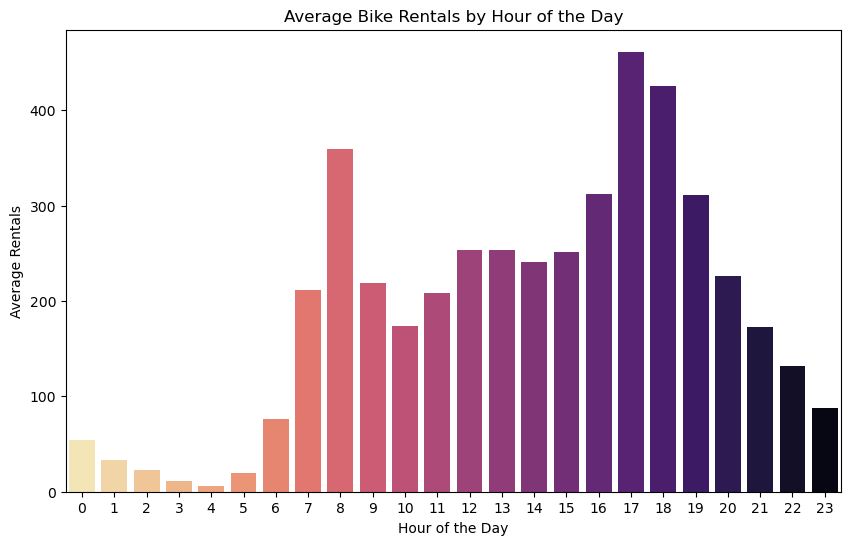

In [24]:
# Calculate the average bike rentals per hour of the day
hourly_data = hour_data.groupby('hour')['total_rentals'].mean()

# Plot the results using a barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_data.index, y=hourly_data.values, palette="magma_r")
plt.title('Average Bike Rentals by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Rentals')
plt.show()

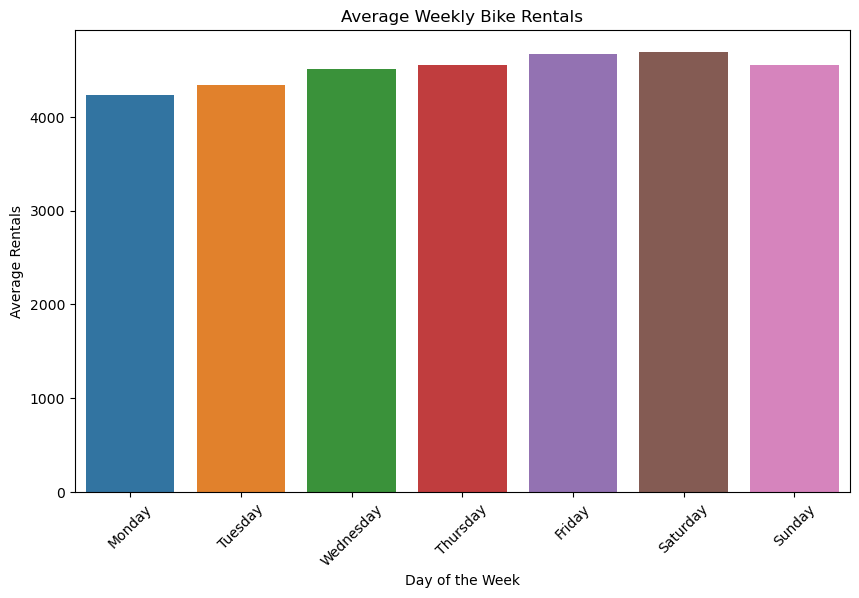

In [25]:
# Define full weekday names and desired order
weekday_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
                 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
order = list(weekday_names.values())

# Replace day_of_week with full names
day_data['day_of_week'] = day_data['day_of_week'].replace(weekday_names)

# Calculate average rentals per day of the week
weekly_data = day_data.groupby('day_of_week')['total_rentals'].mean().reindex(order)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_data.index, y=weekly_data.values, palette="tab10")
plt.title('Average Weekly Bike Rentals')
plt.xlabel('Day of the Week')
plt.ylabel('Average Rentals')
plt.xticks(rotation=45)
plt.show()

### The plot depicts hourly trends across the week, providing insights into bike demand patterns:

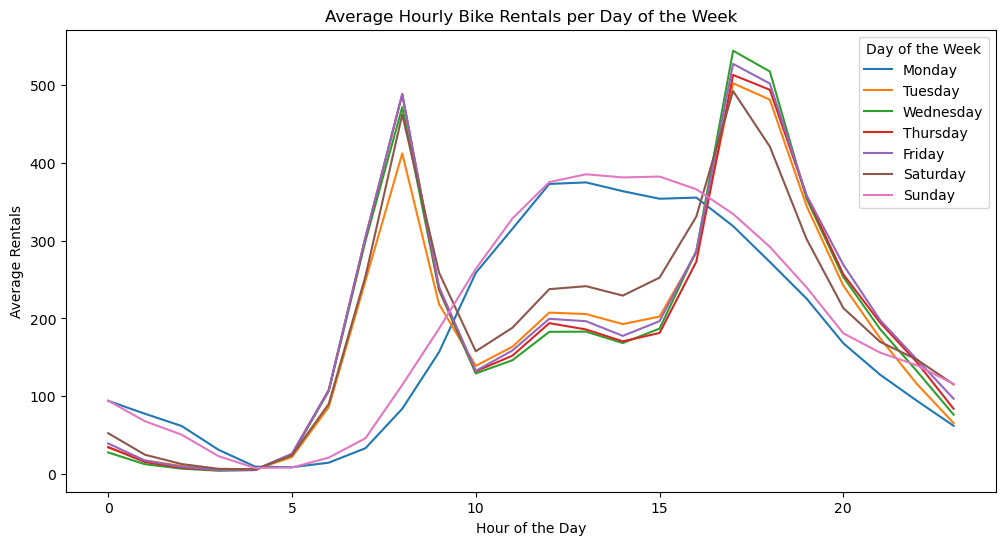

In [26]:
# Replace day_of_week with full names
hour_data['day_of_week'] = hour_data['day_of_week'].replace(weekday_names)

# Group by hour of the day and day of the week to see hourly trends
hourly_trends = hour_data.groupby(['day_of_week', 'hour'])['total_rentals'].mean().reset_index()

# Create a list of days sorted from Monday to Sunday
days_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot hourly trends for each weekday
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_trends, x="hour", y="total_rentals", hue="day_of_week", 
            palette="tab10", hue_order=days_of_week_order)
plt.title('Average Hourly Bike Rentals per Day of the Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Rentals')
plt.legend(title="Day of the Week")
plt.show()


### The plot illustrates monthly trends throughout the year, offering insights into number of bikes rented:

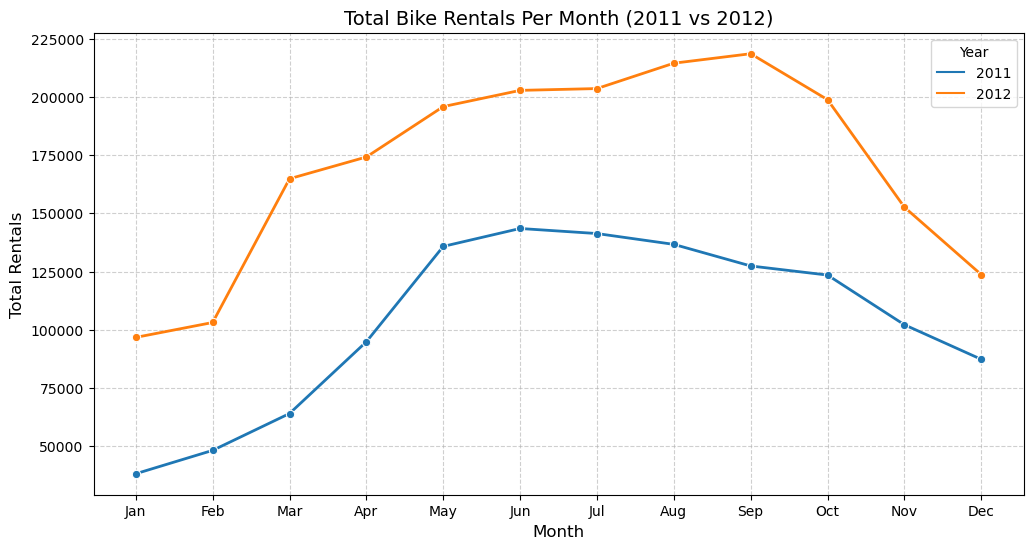

In [27]:
plt.figure(figsize=(12, 6))

# Extract year and month, sum rentals
day_data['year'] = day_data['date'].dt.year
day_data['month'] = day_data['date'].dt.month

monthly_data = day_data.groupby(['year', 'month'])['total_rentals'].sum().reset_index()

# Line plot for each year
sns.lineplot(data=monthly_data, x="month", y="total_rentals", hue="year", marker="o", linewidth=2, palette="tab10")

plt.title('Total Bike Rentals Per Month (2011 vs 2012)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.xticks(range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Year")
plt.show()


In [28]:
# Define a mapping for seasons
season_mapping = {
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Fall"
}

# Map the seasons in the dataset
day_data["season"] = day_data["season"].map(season_mapping)

# Verify the mapping
print(day_data[["season"]].drop_duplicates())


     season
0    Winter
79   Spring
171  Summer
265    Fall


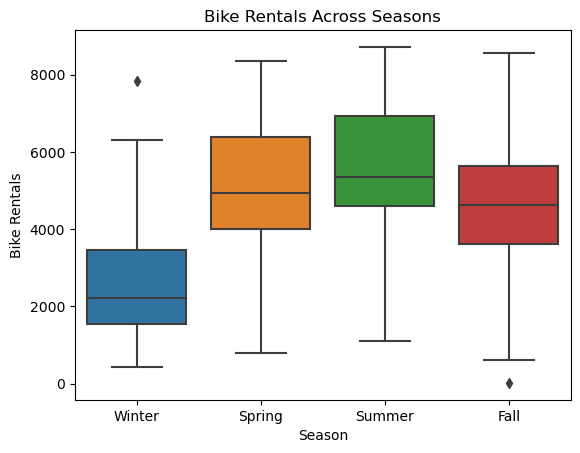

In [29]:
# Box plot of bike rentals across seasons with season names
sns.boxplot(x="season", y="total_rentals", data=day_data)
plt.xlabel("Season")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals Across Seasons")
plt.show()


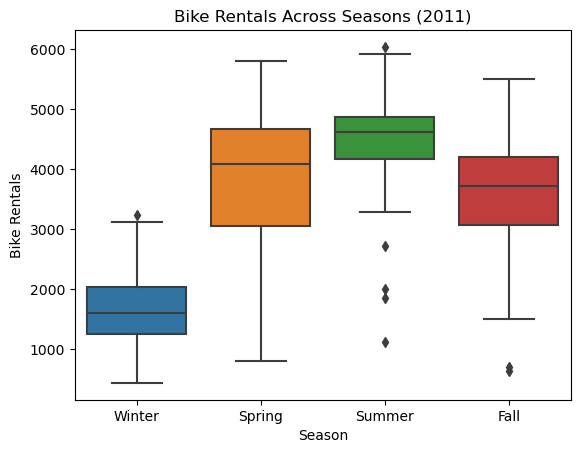

In [30]:
day_data['year'] = day_data['date'].dt.year  # Ensure 'year' column is extracted

sns.boxplot(x="season", y="total_rentals", data=day_data[day_data['year'] == 2011])  # Filter correctly
plt.xlabel("Season")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals Across Seasons (2011)")
plt.show()

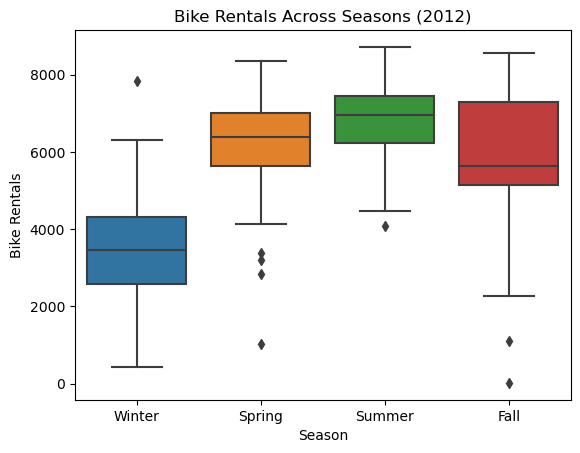

In [31]:
day_data['year'] = day_data['date'].dt.year  # Ensure 'year' column is extracted

sns.boxplot(x="season", y="total_rentals", data=day_data[day_data['year'] == 2012])  # Filter correctly
plt.xlabel("Season")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals Across Seasons (2012)")
plt.show()

### The correlation between weather conditions and bike-sharing demand:

The heatmap visualizes how strongly each weather factor correlates with bike rentals (total_rentals).
Correlation values range from -1 to 1:

    Close to 1: Strong positive relationship (e.g., higher temperature might mean more rentals).
    Close to -1: Strong negative relationship (e.g., higher wind speed might mean fewer rentals).
    Close to 0: Weak or no relationship.

Scatter plots show individual relationships between each weather variable and bike rentals.

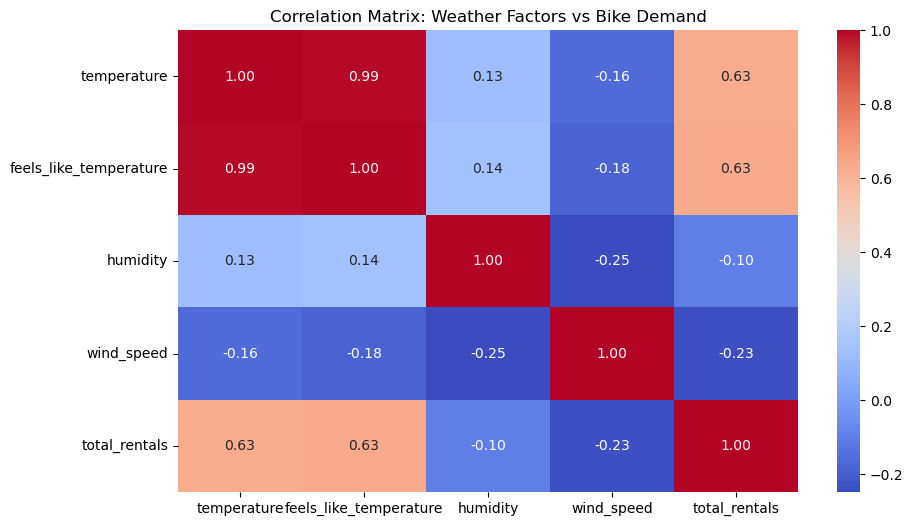

In [33]:
# Select weather-related columns and bike demand
weather_columns = ['temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'total_rentals']
weather_data = day_data[weather_columns]

# Visualize pairwise correlations
plt.figure(figsize=(10, 6))
sns.heatmap(weather_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Weather Factors vs Bike Demand')
plt.show()

The red line from sns.regplot() represents a linear regression line that fits your data, showing the overall trend between the two continuous variables.

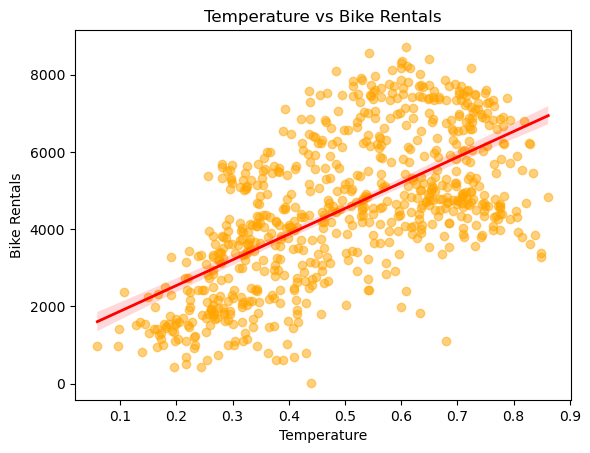

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot with alpha for transparency
plt.scatter(day_data["temperature"], day_data["total_rentals"], alpha=0.5, color="orange")

# Adding a linear trend line using seaborn
sns.regplot(x="temperature", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals")

plt.show()

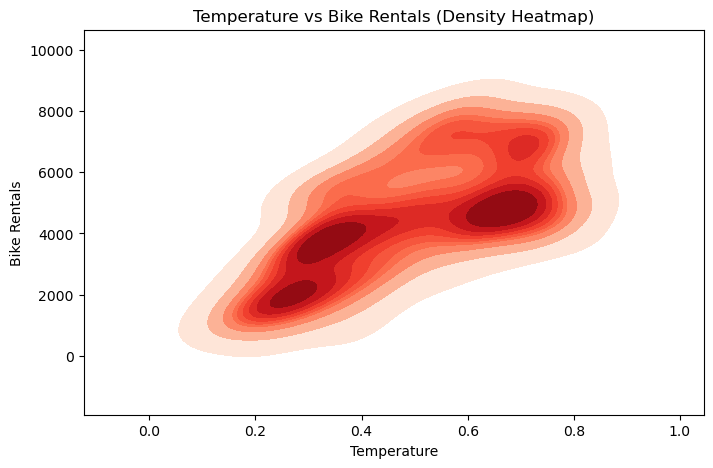

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# KDE (density heatmap)
sns.kdeplot(
    x=day_data["temperature"], 
    y=day_data["total_rentals"], 
    cmap="Reds",  # Heatmap color
    fill=True
)

# Customize plot
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals (Density Heatmap)")

plt.show()

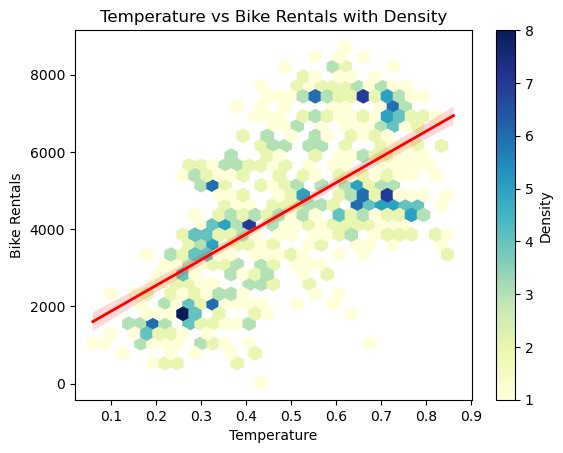

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot with heatmap-like effect (hexbin)
plt.hexbin(day_data["temperature"], day_data["total_rentals"], gridsize=30, cmap="YlGnBu", mincnt=1)

# Adding a color bar to show intensity
plt.colorbar(label='Density')

# Adding a linear trend line using seaborn
sns.regplot(x="temperature", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals with Density")

plt.show()

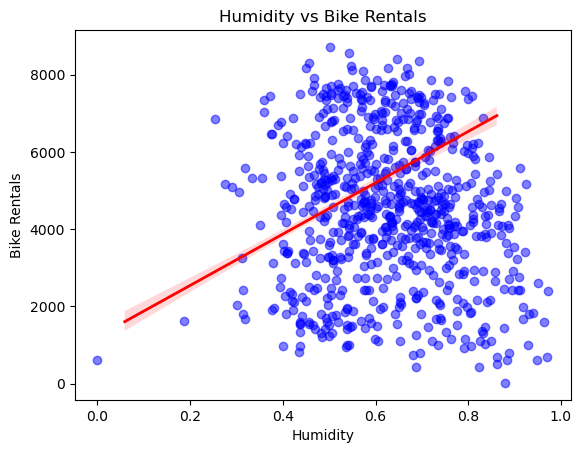

In [37]:
plt.scatter(day_data["humidity"], day_data["total_rentals"], alpha=0.5, color="blue")

# Adding a linear trend line using seaborn 
sns.regplot(x="temperature", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")
plt.title("Humidity vs Bike Rentals")
plt.show()

A bar plot in seaborn (like sns.barplot()) calculates the mean (average) of the y-values for each category on the x-axis by default.

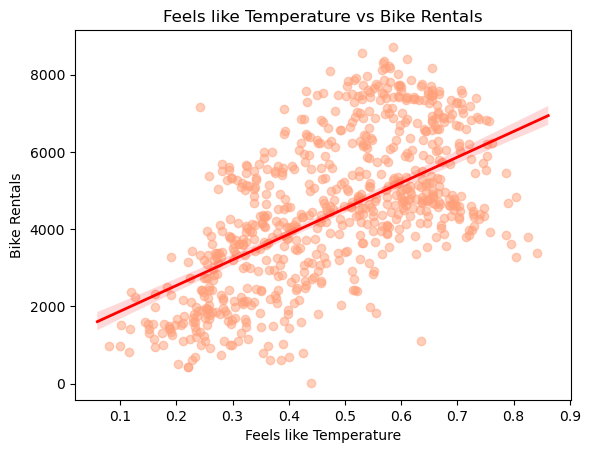

In [38]:
# Scatter plot with alpha for transparency
plt.scatter(day_data["feels_like_temperature"], day_data["total_rentals"], alpha=0.5, color="#FFA07A")

# Adding a linear trend line using seaborn 
sns.regplot(x="temperature", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Feels like Temperature")
plt.ylabel("Bike Rentals")
plt.title("Feels like Temperature vs Bike Rentals")

plt.show()

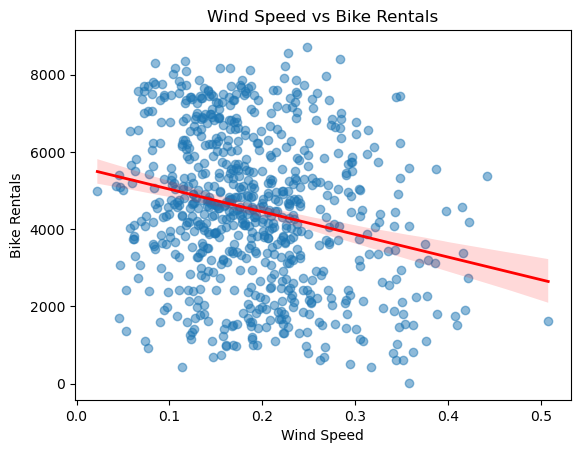

In [39]:
# Scatter plot with alpha for transparency
plt.scatter(day_data["wind_speed"], day_data["total_rentals"], alpha=0.5)

# Adding a linear trend line using seaborn
sns.regplot(x="wind_speed", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Wind Speed")
plt.ylabel("Bike Rentals")
plt.title("Wind Speed vs Bike Rentals")

plt.show()

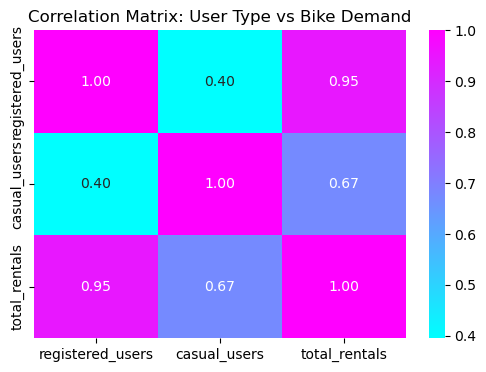

In [40]:
# Select weather-related columns and bike demand
user_columns = ['registered_users', 'casual_users', 'total_rentals']
user_data = day_data[user_columns]

# Visualize pairwise correlations
plt.figure(figsize=(6, 4))
sns.heatmap(user_data.corr(), annot=True, cmap='cool', fmt='.2f')
plt.title('Correlation Matrix: User Type vs Bike Demand')
plt.show()

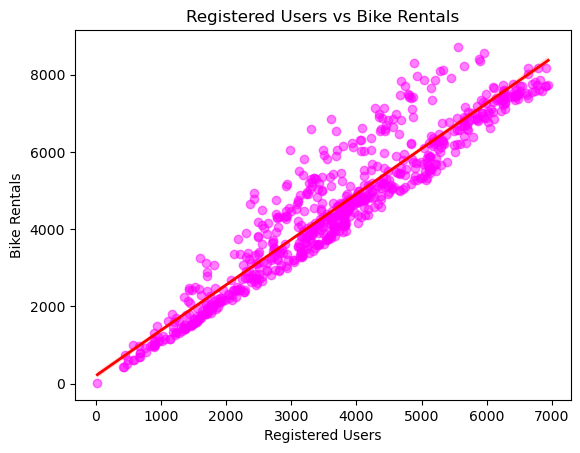

In [41]:
# Scatter plot with alpha for transparency
plt.scatter(day_data["registered_users"], day_data["total_rentals"], alpha=0.5, color="#ff00ff")

# Adding a linear trend line using seaborn
sns.regplot(x="registered_users", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Registered Users")
plt.ylabel("Bike Rentals")
plt.title("Registered Users vs Bike Rentals")

plt.show()

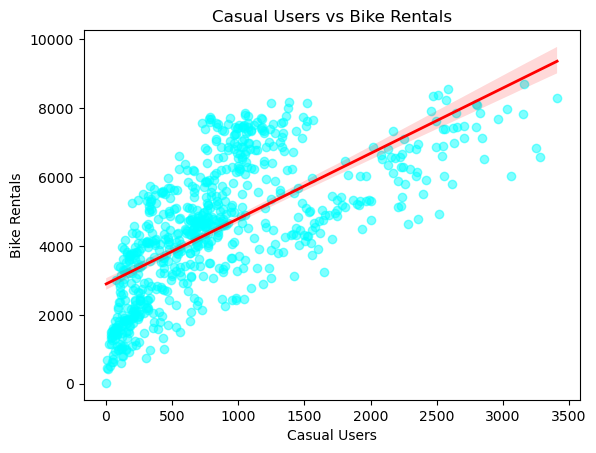

In [42]:
# Scatter plot with alpha for transparency
plt.scatter(day_data["casual_users"], day_data["total_rentals"], alpha=0.5, color="cyan")

# Adding a linear trend line using seaborn 
sns.regplot(x="casual_users", y="total_rentals", data=day_data, scatter=False, color="red", line_kws={"linewidth": 2})

# Customize plot
plt.xlabel("Casual Users")
plt.ylabel("Bike Rentals")
plt.title("Casual Users vs Bike Rentals")

plt.show()

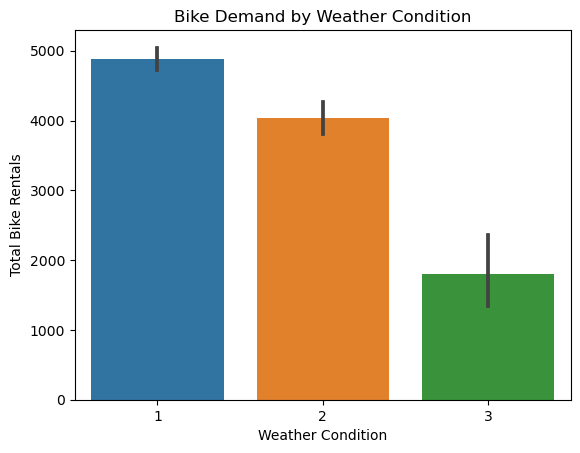

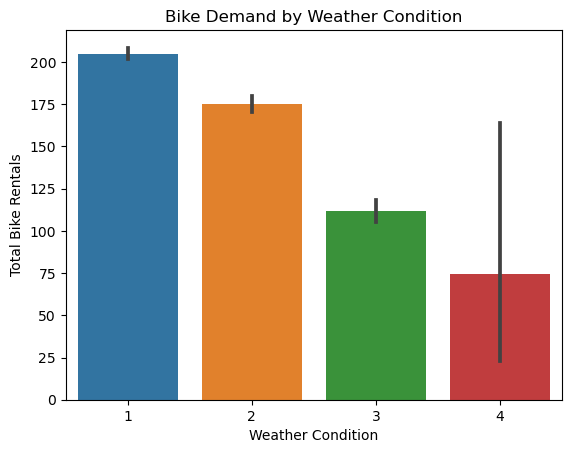

In [44]:
sns.barplot(x="weather_condition", y="total_rentals", data=day_data)
plt.xlabel("Weather Condition")
plt.ylabel("Total Bike Rentals")
plt.title("Bike Demand by Weather Condition")
plt.show()

sns.barplot(x="weather_condition", y="total_rentals", data=hour_data)
plt.xlabel("Weather Condition")
plt.ylabel("Total Bike Rentals")
plt.title("Bike Demand by Weather Condition")
plt.show()

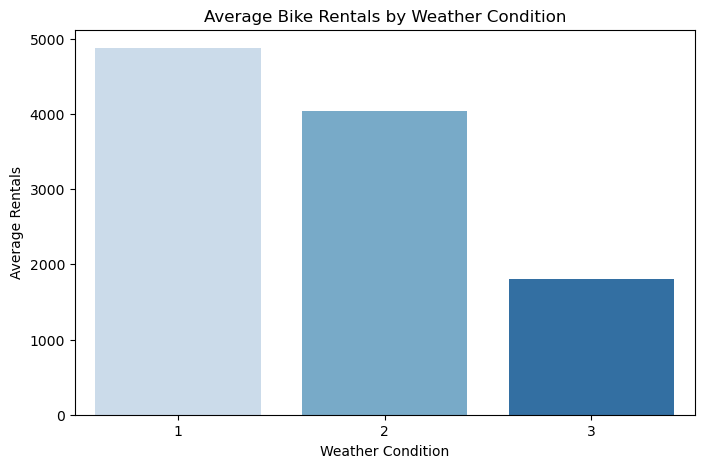

In [45]:
# Group by weather condition and calculate average rentals
weather_data = day_data.groupby('weather_condition')['total_rentals'].mean()

# Plot the results
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_data.index, y=weather_data.values, palette="Blues")
plt.title('Average Bike Rentals by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Rentals')
plt.show()

Fewer people rent bikes in bad weather, leading to inconsistent rental counts.
Some days might have very low rentals, while a few might still have moderate rentals.

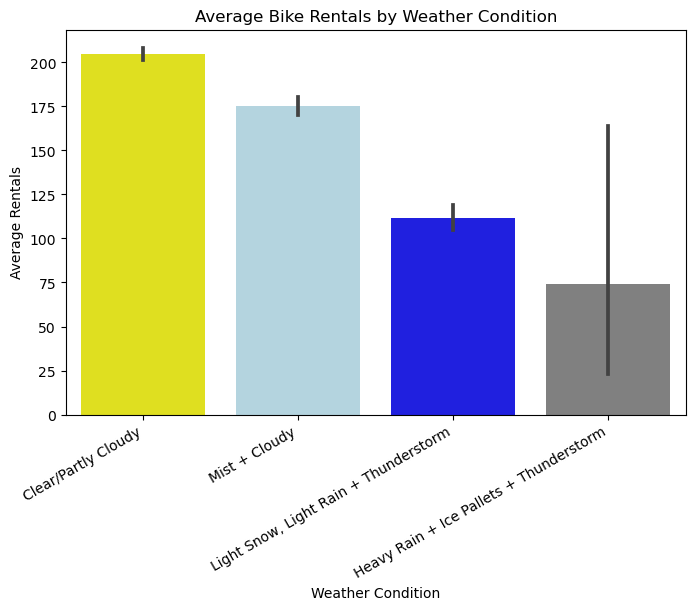

In [46]:
# Define weather condition mapping
weather_sit = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist + Cloudy',
    3: 'Light Snow, Light Rain + Thunderstorm',
    4: 'Heavy Rain + Ice Pallets + Thunderstorm'
}

# Replace numerical weather conditions with descriptive labels
hour_data['weather_condition'] = hour_data['weather_condition'].replace(weather_sit)

# Plot the bar chart (Seaborn will automatically group by and compute mean)
plt.figure(figsize=(8, 5))
sns.barplot(x="weather_condition", y="total_rentals", data=hour_data, palette=['yellow', 'lightblue', 'blue', 'gray']) #ci=None

# Customize labels
plt.title('Average Bike Rentals by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Rentals')
plt.xticks(rotation=30, ha='right')  # Rotate x labels for readability

plt.show()


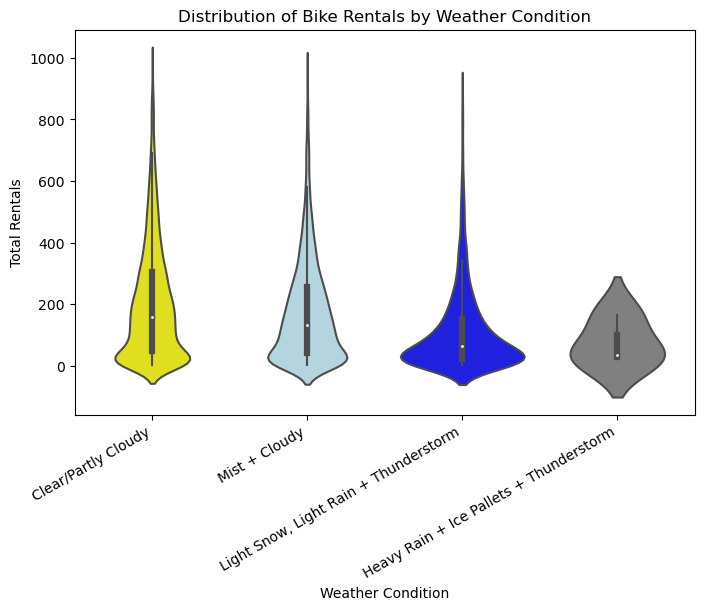

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define weather condition mapping
weather_sit = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist + Cloudy',
    3: 'Light Snow, Light Rain + Thunderstorm',
    4: 'Heavy Rain + Ice Pallets + Thunderstorm'
}

# Replace numerical weather conditions with descriptive labels
hour_data['weather_condition'] = hour_data['weather_condition'].replace(weather_sit)

# Plot the violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(x="weather_condition", y="total_rentals", data=hour_data, palette=['yellow', 'lightblue', 'blue', 'gray'])#, inner="point")

# Customize labels
plt.title('Distribution of Bike Rentals by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Total Rentals')
plt.xticks(rotation=30, ha='right')  # Rotate x labels for readability

plt.show()

Model Predictions on hourly data:

In [43]:
#!pip install xgboost

In [48]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selecting relevant features and target variable
features = ['season', 'year', 'month', 'hour', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
            'temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users', 'registered_users']
target = 'total_rentals'

X = hour_data[features]
y = hour_data[target]

# Convert categorical columns to category dtype and then to integer codes
categorical_columns = ['season', 'year', 'month', 'hour', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition']

for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Training the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

# Making predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\480508746.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes
C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\480508746.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes
C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\480508746.py:18: SettingWithCopyWarning: 
A value is trying to be set o

MAE: 3.623268003533707
MSE: 75.16147367343397
RMSE: 8.669571712226272
R² Score: 0.9984538988283773


In [49]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Splitting into training and testing sets (80% train, 20% test) without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Hyperparameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1],  # Learning rate
    'max_depth': [3, 4, 5],  # Maximum depth of tree
    'min_child_weight': [1, 2, 3],  # Minimum sum of instance weight in a leaf
    'subsample': [0.7, 0.8, 0.9]  # Fraction of samples for training
}

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

# Perform GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# Get the best hyperparameters and print them
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)

# Make predictions with the best model
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.9}
MAE: 3.3960772435533437
MSE: 79.31628977664782
RMSE: 8.905969333915754
R² Score: 0.9983684326216745


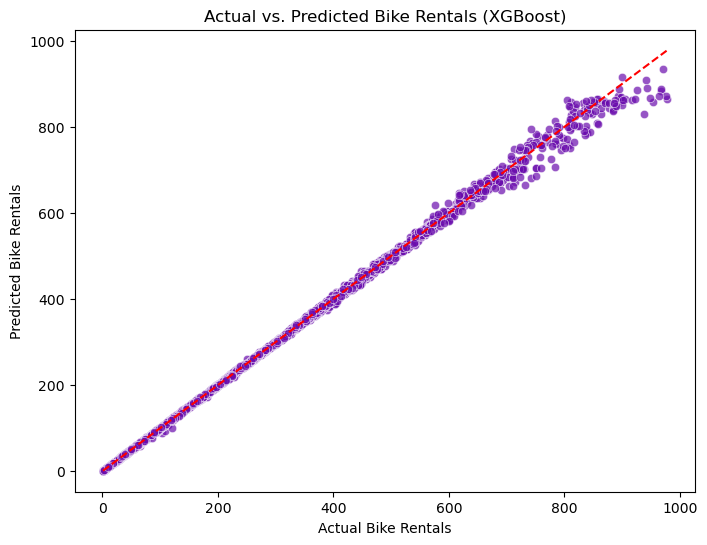

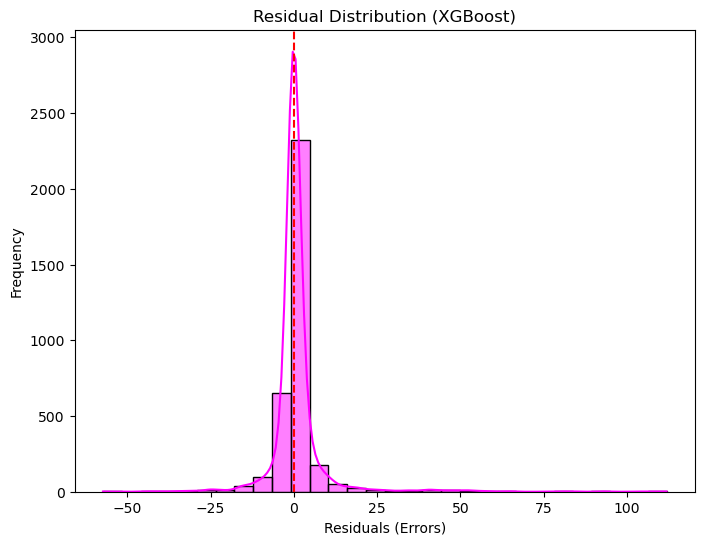

In [51]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.7, color='#6a0dad')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')  # Perfect predictions line
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs. Predicted Bike Rentals (XGBoost)")
plt.show()

# Residual Plot
residuals = y_test - y_pred_xgb
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='#ff00ff')
plt.axvline(0, color='r', linestyle='--')  # Zero error line
plt.xlabel("Residuals (Errors)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (XGBoost)")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Compute residuals
residuals = y_test - y_pred_xgb

SVR

Epsilon (ε) in SVR (Support Vector Regression) specifically applies to regression problems, where the goal is to predict continuous values. In contrast, SVM (Support Vector Machine) uses a similar concept of margin but for classification tasks.

In SVR (Support Vector Regression), epsilon (ε) defines the margin of tolerance where no penalty is given for errors; points within this margin are considered correctly predicted, and errors outside the margin incur a cost.

In [54]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selecting relevant features and target variable
features = ['season', 'year', 'month', 'hour', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
            'temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users', 'registered_users']
target = 'total_rentals'

X = hour_data[features]
y = hour_data[target]

# Convert categorical columns to category dtype and then to integer codes
categorical_columns = ['season', 'year', 'month', 'hour', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition']

for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Training the SVR model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)  # RBF kernel, C controls regularization, epsilon defines error margin
svr_model.fit(X_train, y_train)

# Making predictions
y_pred_svr = svr_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\199890592.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes
C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\199890592.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes
C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\199890592.py:18: SettingWithCopyWarning: 
A value is trying to be set o

MAE: 0.6962772911496437
RMSE: 6.152629287085416
R² Score: 0.9992213108569997


In [57]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Splitting into training and testing sets (80% train, 20% test) without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Scaling the data (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter grid for SVR
param_grid_svr = {
    'C': [10, 100, 1000],  # Regularization parameter 
    'epsilon': [0.05, 0.1, 0.2],  # Margin of error (higher epsilon reduces model complexity)
    'kernel': ['linear'],  # Kernel type
    'gamma': ['auto']  # Kernel coefficient (lower values reduce overfitting)
}

# Initialize SVR model
svr_model = SVR()

# Perform GridSearchCV with 10-fold cross-validation to improve generalization
grid_search_svr = GridSearchCV(estimator=svr_model, param_grid=param_grid_svr, cv=10, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_svr.fit(X_train_scaled, y_train)

# Get the best hyperparameters and print them
print("Best parameters for SVR:", grid_search_svr.best_params_)

# Make predictions with the best model
best_svr_model = grid_search_svr.best_estimator_
y_pred_svr = best_svr_model.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best parameters for SVR: {'C': 100, 'epsilon': 0.05, 'gamma': 'auto', 'kernel': 'linear'}
MAE: 0.028706651220844127
MSE: 0.0010342940309481085
RMSE: 0.032160442020409304
R² Score: 0.9999999787241637


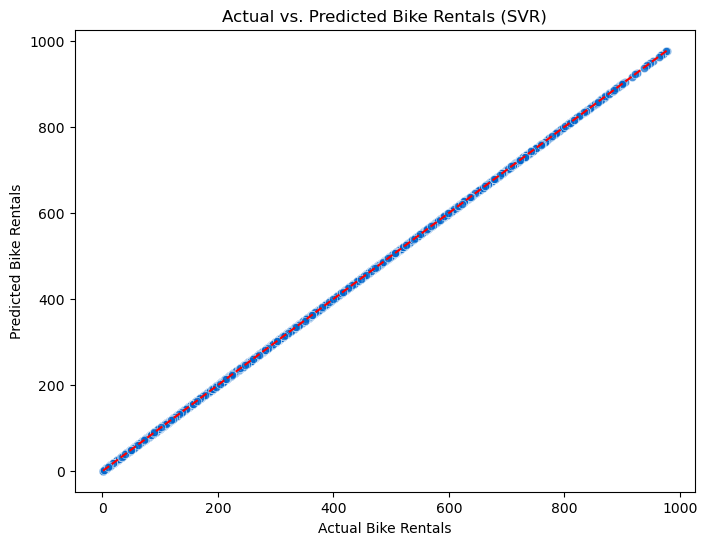

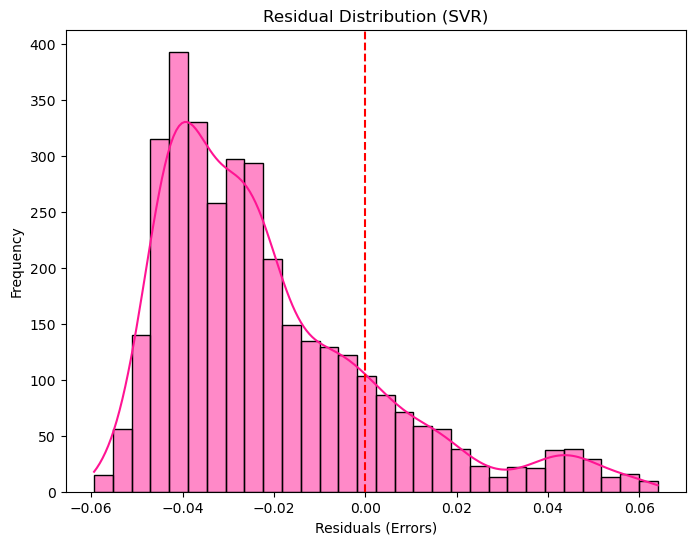

In [58]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.7, color='#0066cc')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')  # Perfect predictions line
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs. Predicted Bike Rentals (SVR)")
plt.show()

# Residual Plot
residuals = y_test - y_pred_svr
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='#ff1493')
plt.axvline(0, color='r', linestyle='--')  # Zero error line
plt.xlabel("Residuals (Errors)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (SVR)")
plt.show()

Model Predictions on daily data:

In [63]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selecting relevant features and target variable
features = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
            'temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users', 'registered_users']
target = 'total_rentals'

X = day_data[features]
y = day_data[target]

# Convert categorical columns to category dtype and then to integer codes
categorical_columns = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition']

for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#, shuffle=False)

# Training the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

# Making predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\3356991853.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes


MAE: 68.06152634393601
MSE: 9911.241480520008
RMSE: 99.55521824856801
R² Score: 0.9975282961525483


In [64]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Splitting into training and testing sets (80% train, 20% test) without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Hyperparameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1],  # Learning rate
    'max_depth': [3, 4, 5],  # Maximum depth of tree
    'min_child_weight': [1, 2, 3],  # Minimum sum of instance weight in a leaf
    'subsample': [0.7, 0.8, 0.9]  # Fraction of samples for training
}

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

# Perform GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# Get the best hyperparameters and print them
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)

# Make predictions with the best model
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.7}
MAE: 186.77721711243092
MSE: 80007.91311956063
RMSE: 282.8567006799744
R² Score: 0.977232970091502


In [69]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selecting relevant features and target variable
features = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
            'temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users', 'registered_users']
target = 'total_rentals'

X = day_data[features]
y = day_data[target]

# Convert categorical columns to category dtype and then to integer codes
categorical_columns = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition']

for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#, shuffle=False)

# Training the SVR model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)  # RBF kernel, C controls regularization, epsilon defines error margin
svr_model.fit(X_train, y_train)

# Making predictions
y_pred_svr = svr_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

MAE: 111.82925085131164
RMSE: 195.24215018781308
R² Score: 0.9904936119151202


C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\1474433779.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes


In [70]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Splitting into training and testing sets (80% train, 20% test) without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Scaling the data (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter grid for SVR
param_grid_svr = {
    'C': [10, 100, 1000],  # Regularization parameter 
    'epsilon': [0.05, 0.1, 0.2],  # Margin of error (higher epsilon reduces model complexity)
    'kernel': ['linear'],  # Kernel type
    'gamma': ['auto']  # Kernel coefficient (lower values reduce overfitting)
}

# Initialize SVR model
svr_model = SVR()

# Perform GridSearchCV with 10-fold cross-validation to improve generalization
grid_search_svr = GridSearchCV(estimator=svr_model, param_grid=param_grid_svr, cv=10, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_svr.fit(X_train_scaled, y_train)

# Get the best hyperparameters and print them
print("Best parameters for SVR:", grid_search_svr.best_params_)

# Make predictions with the best model
best_svr_model = grid_search_svr.best_estimator_
y_pred_svr = best_svr_model.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best parameters for SVR: {'C': 100, 'epsilon': 0.05, 'gamma': 'auto', 'kernel': 'linear'}
MAE: 0.039152264103814886
MSE: 0.002228411192889502
RMSE: 0.04720605038434694
R² Score: 0.9999999993658839


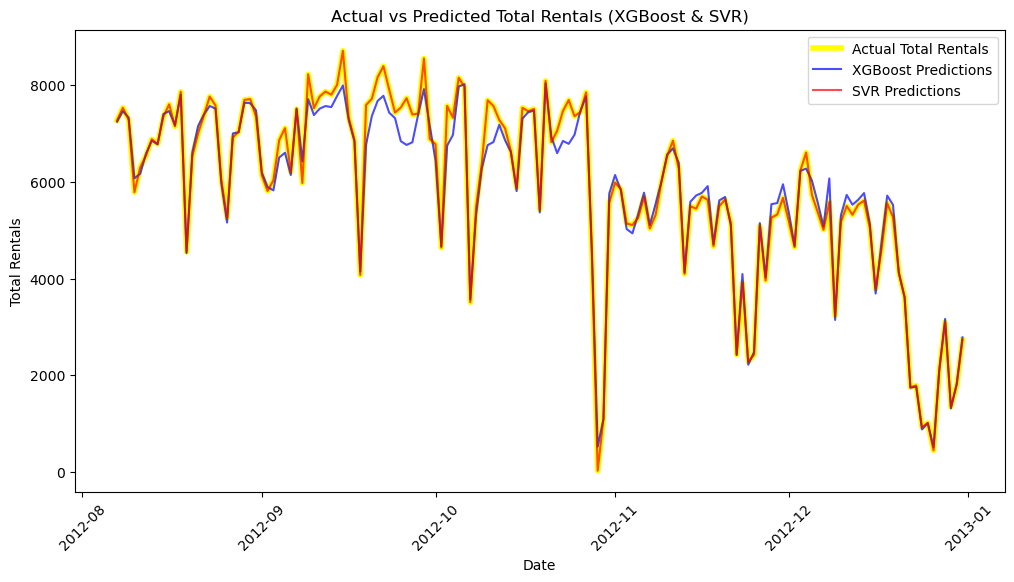

In [71]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert date column to datetime
day_data['date'] = pd.to_datetime(day_data['date'])

# Sort entire dataset by date
day_data = day_data.sort_values(by='date')

# Separate train and test data
train_dates = day_data.iloc[:len(y_train)]['date']
test_dates = day_data.iloc[len(y_train):]['date']

# Ensure that predictions are the same length as y_test
y_pred_xgb = y_pred_xgb[:len(y_test)]  # Truncate to match the length of y_test
y_pred_svr = y_pred_svr[:len(y_test)]  # Truncate to match the length of y_test

# Plotting the time series data
plt.figure(figsize=(12, 6))

# Plot Actual values (using test_dates as x-axis for actual values)
plt.plot(test_dates, y_test, label="Actual Total Rentals", color='yellow', linewidth=4)

# Plot XGBoost Predictions
plt.plot(test_dates, y_pred_xgb, label="XGBoost Predictions", color='blue', alpha=0.7)

# Plot SVR Predictions
plt.plot(test_dates, y_pred_svr, label="SVR Predictions", color='red', alpha=0.7)

# Labeling the plot
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.title("Actual vs Predicted Total Rentals (XGBoost & SVR)")

# Rotate x-axis labels to make them readable
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show the plot
plt.show()

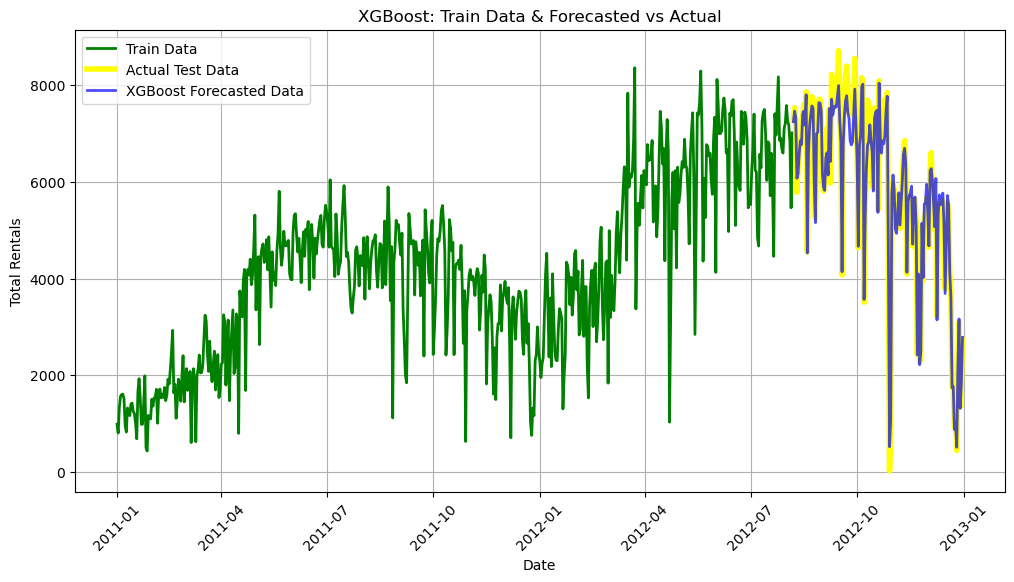

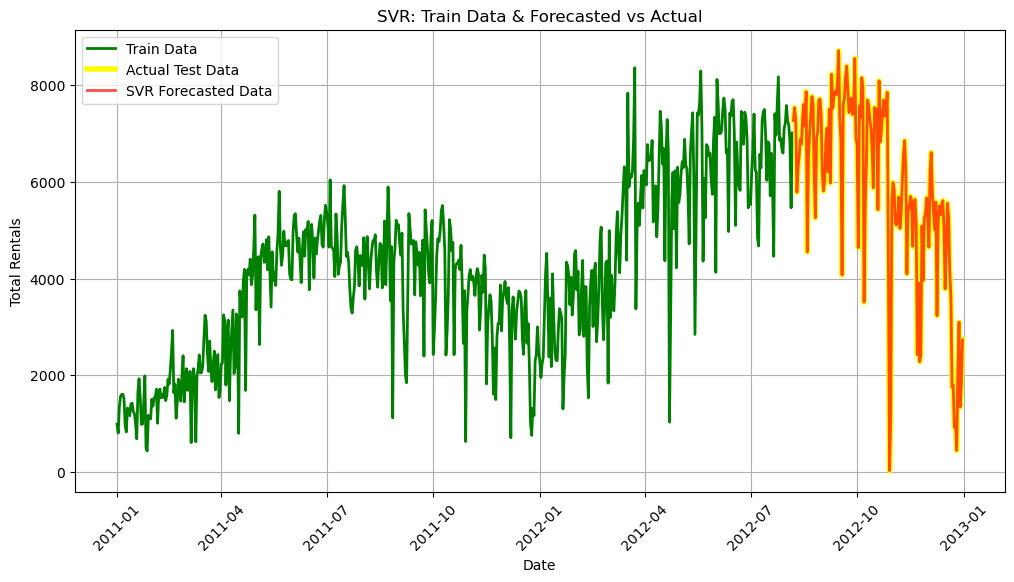

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert date column to datetime and sort the dataset
day_data['date'] = pd.to_datetime(day_data['date'])
day_data = day_data.sort_values(by='date')

# Separate train and test dates
train_dates = day_data.iloc[:len(y_train)]['date']
test_dates = day_data.iloc[len(y_train):]['date']
all_dates = day_data['date']  # Full timeline

# Combine train and test actual values
all_actual = np.concatenate([y_train, y_test])

# Predictions
all_pred_xgb = np.concatenate([best_xgb_model.predict(X_train), y_pred_xgb])
all_pred_svr = np.concatenate([best_svr_model.predict(X_train_scaled), y_pred_svr])

## Plot 1: XGBoost - Train Data & Predictions
plt.figure(figsize=(12, 6))
plt.plot(train_dates, y_train, label="Train Data", color='green', linewidth=2)  # Train data
plt.plot(test_dates, y_test, label="Actual Test Data", color='yellow', linewidth=4)  # Actual test data
plt.plot(test_dates, y_pred_xgb, label="XGBoost Forecasted Data", color='blue', linewidth=2, alpha=0.7)  # XGBoost prediction
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.title("XGBoost: Train Data & Forecasted vs Actual")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Plot 2: SVR - Train Data & Predictions
plt.figure(figsize=(12, 6))
plt.plot(train_dates, y_train, label="Train Data", color='green', linewidth=2)  # Train data
plt.plot(test_dates, y_test, label="Actual Test Data", color='yellow', linewidth=4)  # Actual test data
plt.plot(test_dates, y_pred_svr, label="SVR Forecasted Data", color='red', linewidth=2, alpha=0.7)  # SVR prediction
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.title("SVR: Train Data & Forecasted vs Actual")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [73]:
#!pip install shap

C:\Users\h_ale\AppData\Local\Temp\ipykernel_7048\934584638.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes


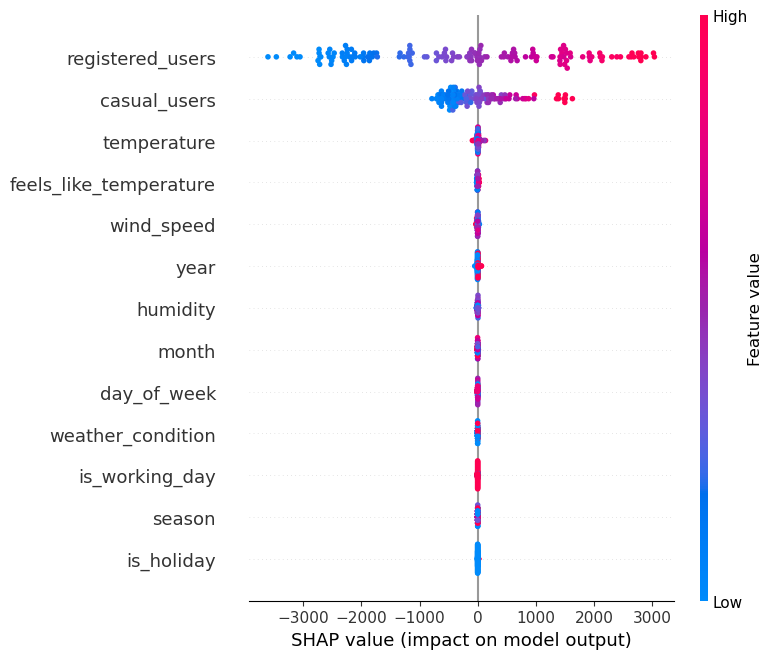

In [74]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Selecting relevant features and target variable
features = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
            'temperature', 'feels_like_temperature', 'humidity', 'wind_speed', 'casual_users', 'registered_users']
# Select features and target variable
target = "total_rentals"

X = day_data[features]
y = day_data[target]

# Convert categorical columns to category dtype and then to integer codes
categorical_columns = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition']

for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes  # Convert categories to numeric codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (optional, helps some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# SHAP feature importance analysis
explainer = shap.Explainer(model)
shap_values = explainer(X_test_scaled)

# Plot SHAP feature importance
shap.summary_plot(shap_values, X_test, feature_names=features)

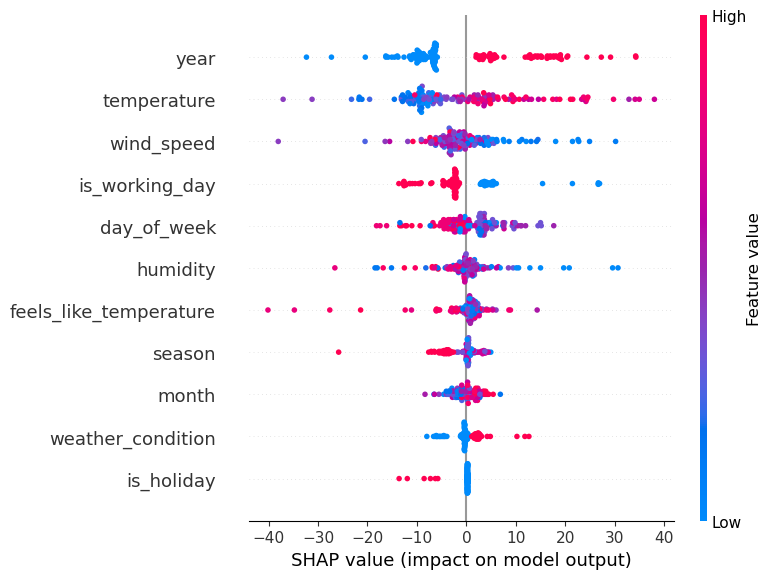

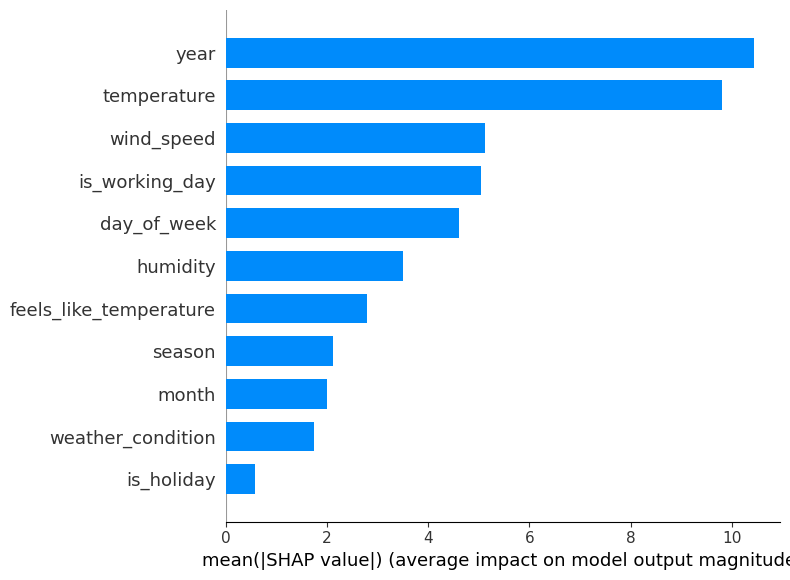

In [75]:
import shap

# Create a SHAP explainer for the trained XGBoost model
explainer = shap.Explainer(best_xgb_model, X_train)

# Get SHAP values for the test set
shap_values = explainer(X_test)

# Specify your optional features
optional_features = ['season', 'year', 'month', 'is_holiday', 'day_of_week', 'is_working_day', 'weather_condition', 
                     'temperature', 'feels_like_temperature', 'humidity', 'wind_speed'] 

# Subset the test data to include only the optional features
X_test_optional = X_test[optional_features]

# Extract SHAP values for the optional features subset (this will match the shape of X_test_optional)
shap_values_optional = shap_values[:, optional_features]

# Visualize the feature importance based on SHAP values (using only the optional features)
shap.summary_plot(shap_values_optional, X_test_optional, feature_names=optional_features)

# Create a bar plot for the top 10 important optional features
shap.summary_plot(shap_values_optional, X_test_optional, plot_type="bar", feature_names=optional_features)